# Screening for a winter proof portfolio

In [1]:
from fins.terminal import *

filename_candidates_raw = "candidates_raw.Basket"
# Delete(filename_candidates_raw)
candidates = Get(filename_candidates_raw)
if not candidates:
    candidates = Screen(mcap_min = 2 * Billion, limit=5000)(Mcap().min(1 * Billion)).basket()
    print(f"Candidates for further screening: {len(candidates)}")
    candidates = candidates((Inception().max("2015-01-01")) >> Update(older_than="2025-06-01") >> Alive().true()).basket()
    Put(candidates, "candidates_raw")


Loaded Basket: /candidates_raw.Basket


In [3]:
cagr_2021_post_covid = Cagr(date_from="2021-11-22", date_to="2022-12-05", alias="cagr_2021")
cagr_2018_sell_off = Cagr(date_from="2018-10-01", date_to="2018-12-31")
cagr_2015_drawdown = Cagr(date_from="2015-06-22", date_to="2015-08-29")
cagr_2008_bfc = Cagr(date_from="2007-10-15", date_to="2009-01-26")

good_in_2021_file = "good_in_2021.Basket"
good_in_2021 = Get(good_in_2021_file)
if not good_in_2021:
    good_in_2021 = candidates(cagr_2021_post_covid.min(0))
    Put(good_in_2021, "good_in_2021")

favs_2021 = Basket(
    ANET, # strong growth, ignored covid
	PANW, # strong growth, ignored covid
	TSCO, # Tractor Supply Company, nice neg-corr, lan alden: overstreched (?)
    MUSA, # Murphy USA, Retailer, defensive, currently (06-2025) in a dip
	ENSG, # Ensign Group, beautiful medical
	PGR, # Progressive Corp (Insurance), beautiful longterm chart
    ABBV, # drug manufacturing
)

buying_opportunities = Basket(
    UNH, # heave dip
)

watch_for_dips = Basket(
    UI, # Ubiquity, strong growth, volatile
	FN, # Fabrinet, harware producer, great growth
)

# look for dips in defensive! pretty safe to recover
defensive  = Basket(
	VDC, # pure play definsive staples - with dips once in a while
	VPU, # pure play defensive utilities - with dips once in a while
	SO, # sother company - electrics
	ADP, # defensive tech ~15% p.A
)

deselect = Basket(
	INUTX, # boring
)

good_in_2021.df()


Entity not found: /good_in_2021.Basket
Plugin: Cagr(alias='cagr_2021', date_from='2021-11-22', date_to='2022-12-05', year=None, resolution='m')
Computing cagr_2021 3058 items...
Completed 3058/3058 in 29s (102.6/s)s left
Finished pipeline - final basket has 572 items
Saved Basket: /good_in_2021.Basket


,ticker,weight,cagr_2021
0,AAPL,1.0,0.046807
1,BCH,1.0,0.096844
2,TLK,1.0,0.114304
3,AMX,1.0,0.119461
4,BRK-A,1.0,0.035992
...,...,...,...
567,STRA,1.0,0.049724
568,STNG,1.0,2.087789
569,EFSC,1.0,0.148189
570,ACHC,1.0,0.336946


In [4]:
details = Name() >> Industry() >> Sector() >> Mcap().log()
quality_gate = Ragr().min(0.05, subfield="Med").min(0.15, subfield="Avg").min(0.15, subfield="Med").max(0.8, subfield="Sigma") >> Ratio("RAGR[Med]", "RAGR[Sigma]").min(0.4)

fine_basket = good_in_2021.basket()(details >> quality_gate)
fine_basket.df()


Plugin: Name(alias=None)
Computing Name 572 items...
Completed 572/572 in 0s (0.0/s)0s left
Plugin: Industry(alias=None)
Computing Industry 572 items...
Completed 572/572 in 0s (6290.5/s)left
Plugin: Sector(alias=None)
Computing Sector 572 items...
Completed 572/572 in 0s (7027.3/s)left
Plugin: Mcap(alias=None)
Computing MCap 572 items...
Completed 572/572 in 0s (7166.3/s)left
Plugin: Ragr(alias=None, date_from=None, date_to=None)
Computing RAGR 572 items...
Completed 572/572 in 8s (65.3/s)s left
Plugin: Ratio('RAGR[Med]', 'RAGR[Sigma]', alias=None)
Finished pipeline - final basket has 111 items


,ticker,weight,Name,Industry,Sector,MCap,RAGR[Avg],RAGR[Med],RAGR[Sigma],RAGR[Med]/RAGR[Sigma]
0,AAPL,1.0,Apple Inc.,Consumer Electronics,Technology,12.477597,0.325575,0.246706,0.580917,0.424684
1,BRK-A,1.0,Berkshire Hathaway Inc.,Insurance - Diversified,Financial Services,12.020853,0.214814,0.181269,0.264819,0.684501
2,COST,1.0,Costco Wholesale Corporation,Discount Stores,Consumer Defensive,11.639385,0.231614,0.20587,0.339487,0.606415
3,ABBV,1.0,AbbVie Inc.,Drug Manufacturers - General,Healthcare,11.518443,0.208616,0.20471,0.225226,0.908907
4,UNH,1.0,UnitedHealth Group Incorporated,Medical - Healthcare Plans,Healthcare,11.438572,0.303395,0.25627,0.489168,0.52389
...,...,...,...,...,...,...,...,...,...,...
106,HOG,1.0,"Harley-Davidson, Inc.",Auto - Recreational Vehicles,Consumer Cyclical,9.457813,0.205522,0.175511,0.40576,0.43255
107,USAC,1.0,"USA Compression Partners, LP",Oil & Gas Equipment & Services,Energy,9.457731,0.187403,0.15949,0.379513,0.420248
108,ENVA,1.0,"Enova International, Inc.",Financial - Credit Services,Financial Services,9.449628,0.331643,0.259574,0.617097,0.420638
109,HURN,1.0,Huron Consulting Group Inc.,Consulting Services,Industrials,9.368454,0.157774,0.163849,0.382106,0.428805


Plugin: MonthlyClose(alias=None, ticker=None, resolution='m', metric='close')
Computing MonthlyClose 399 items...
Completed 399/399 in 0s (2148.6/s)eft
Plugin: PlotEach(alias=None)


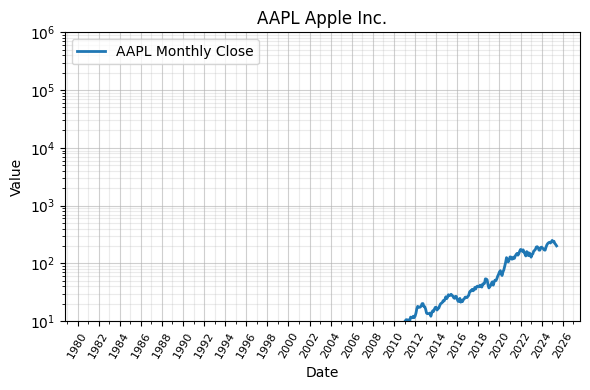

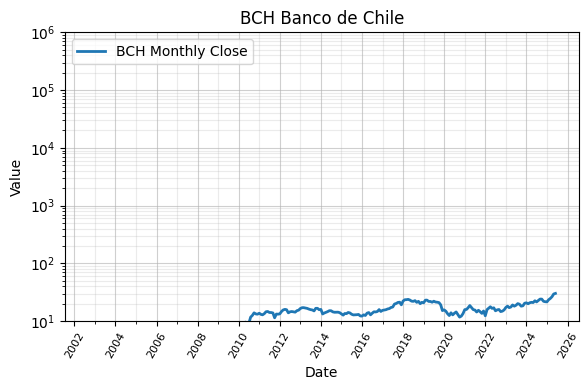

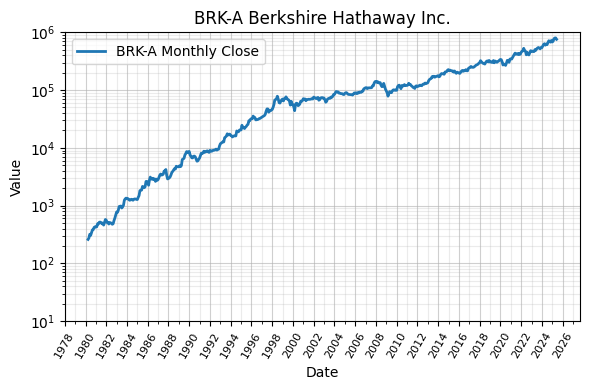

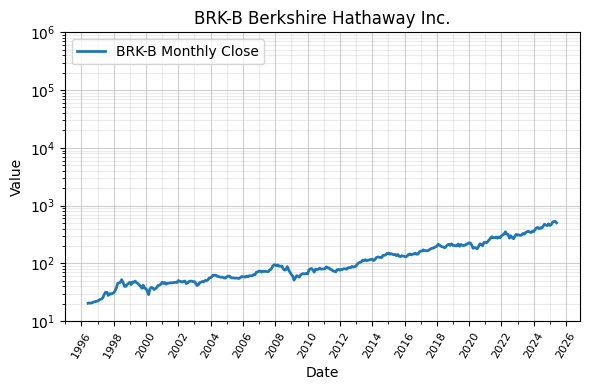

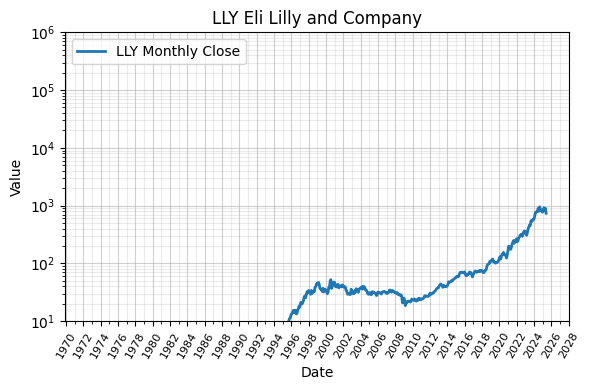

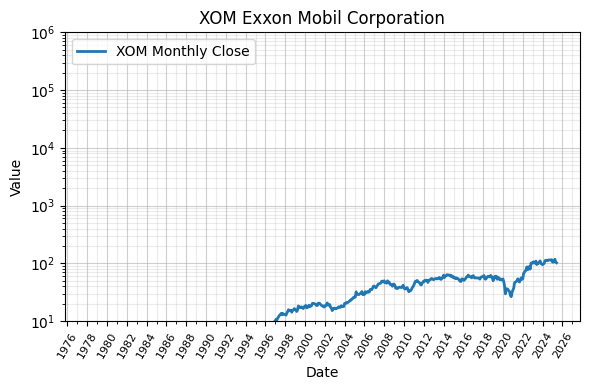

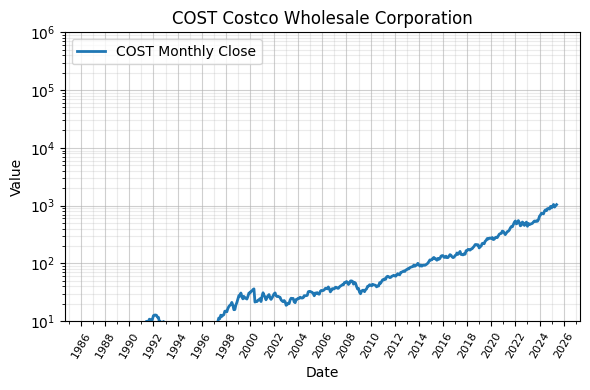

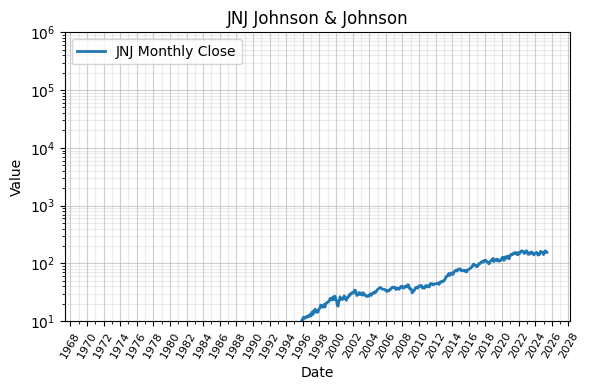

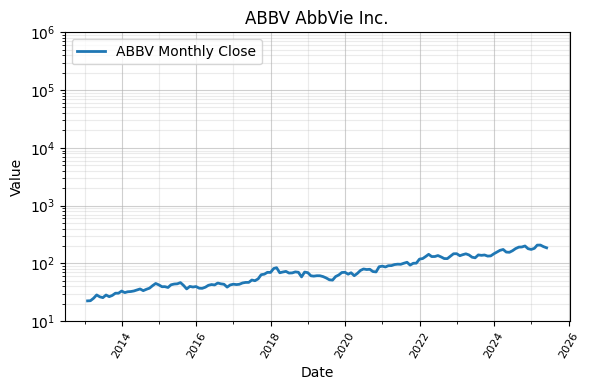

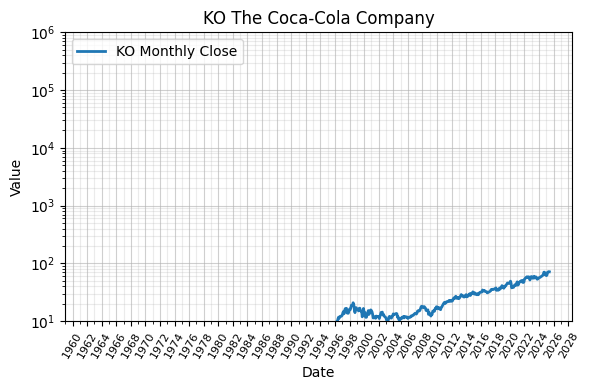

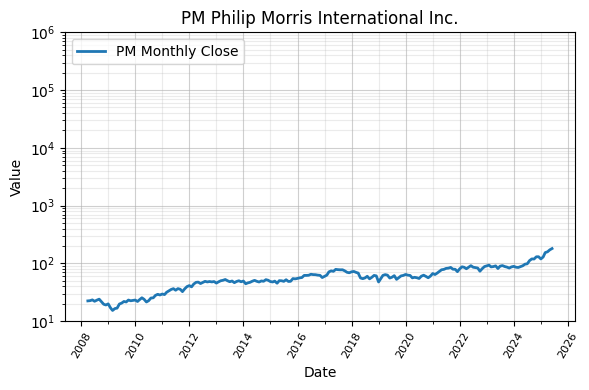

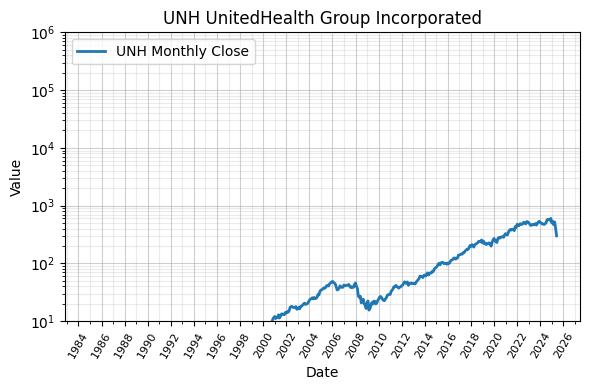

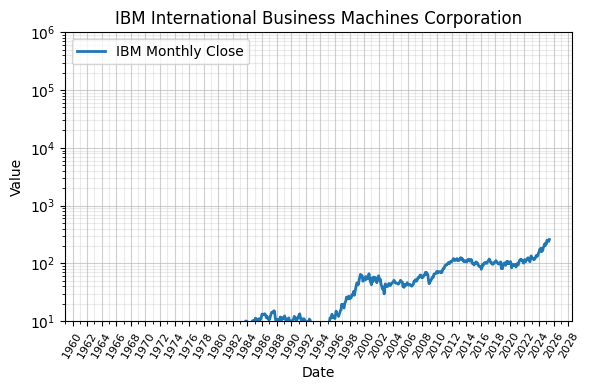

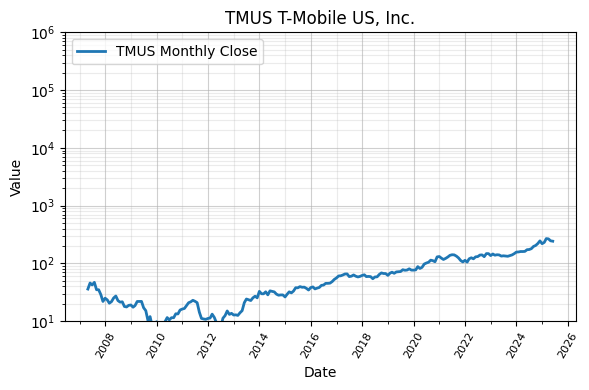

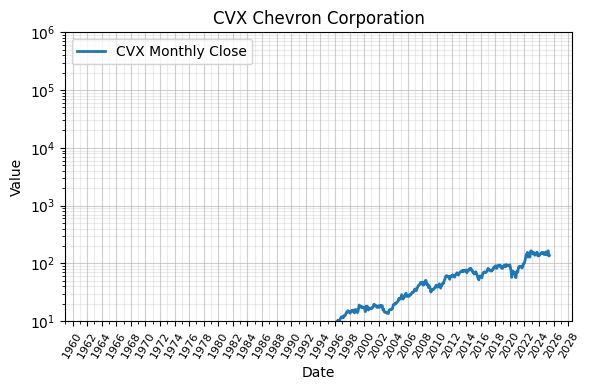

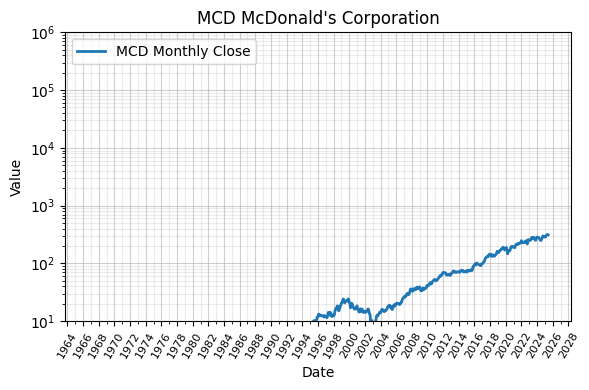

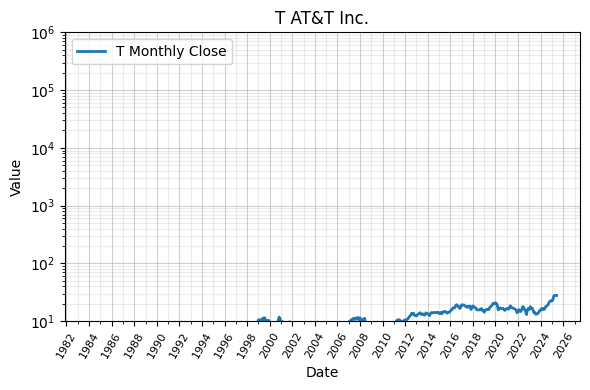

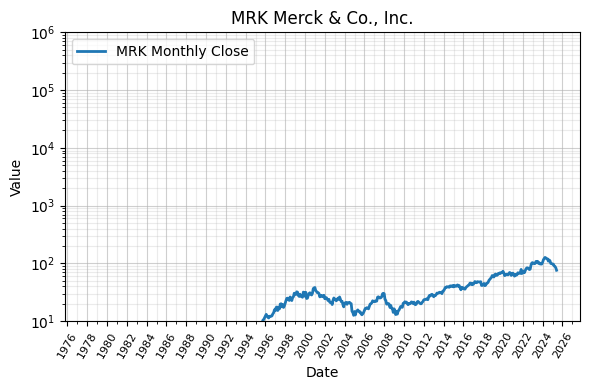

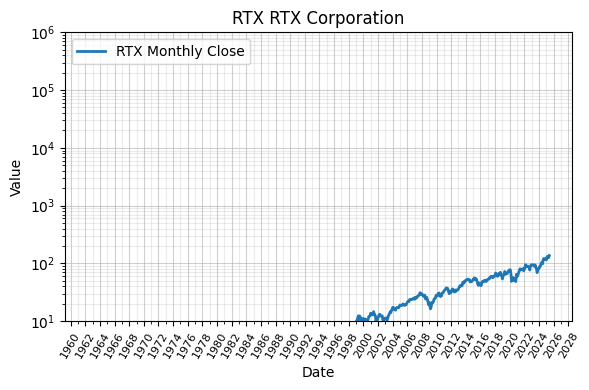

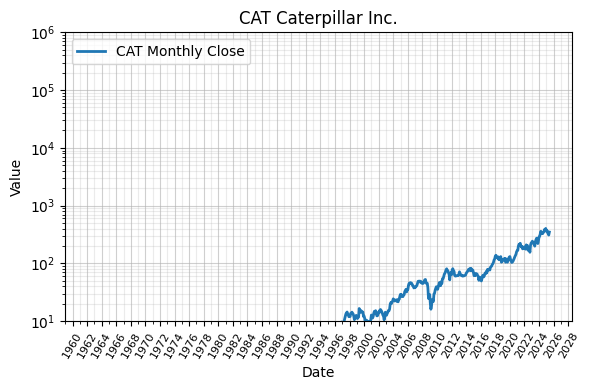

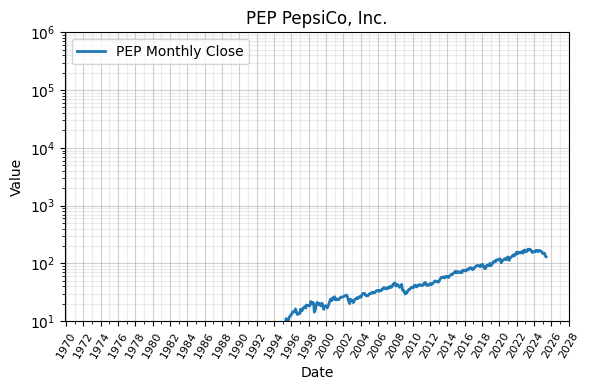

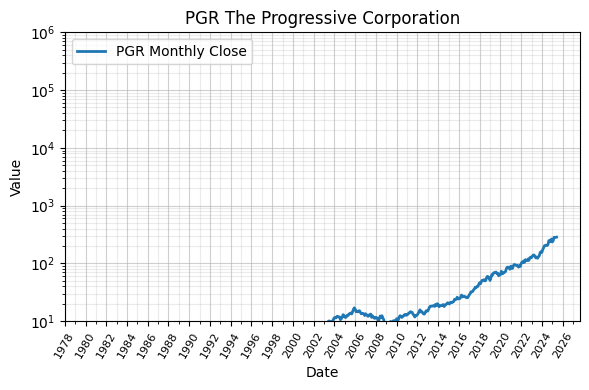

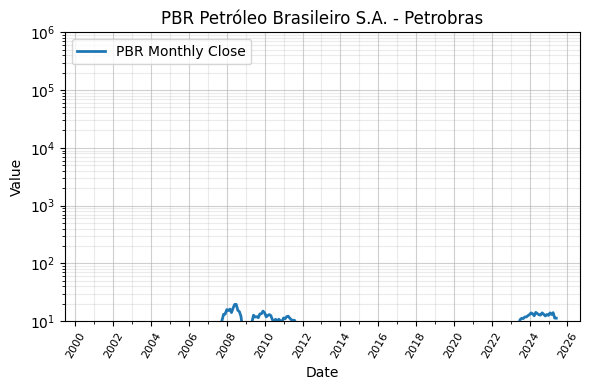

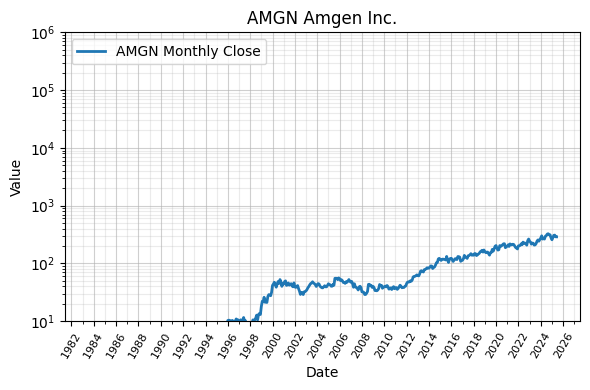

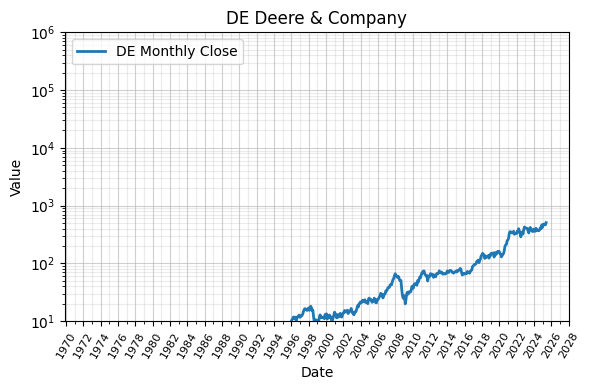

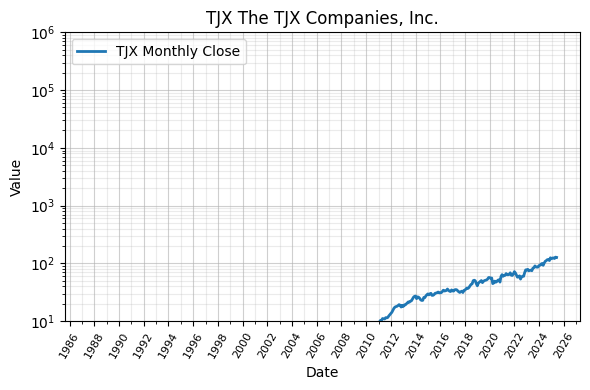

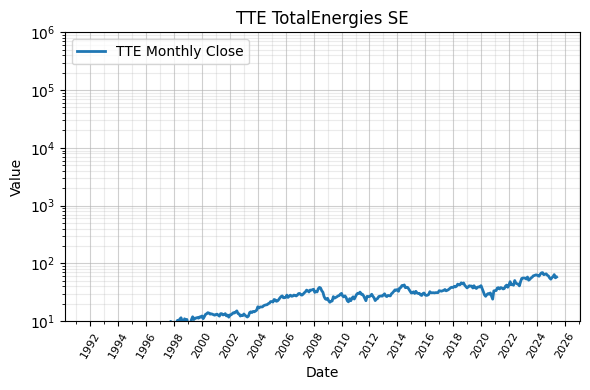

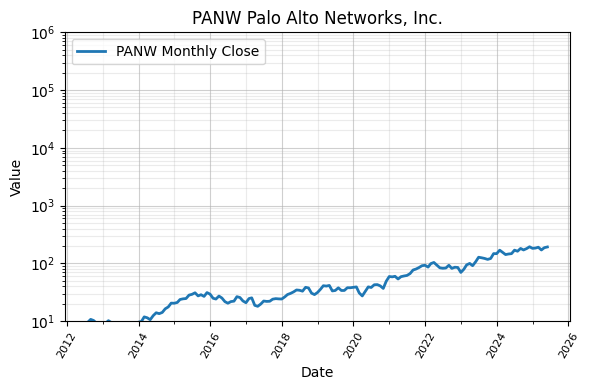

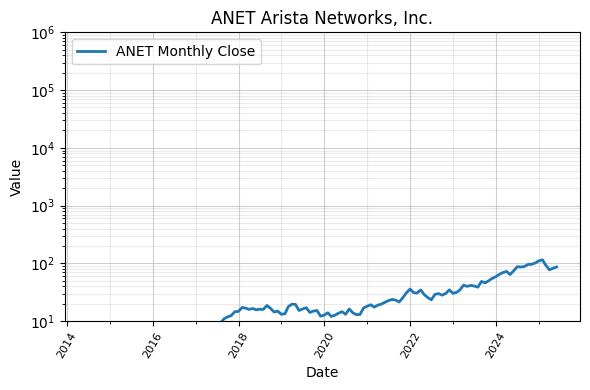

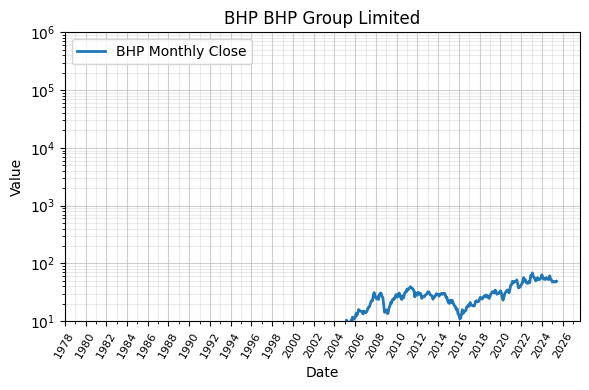

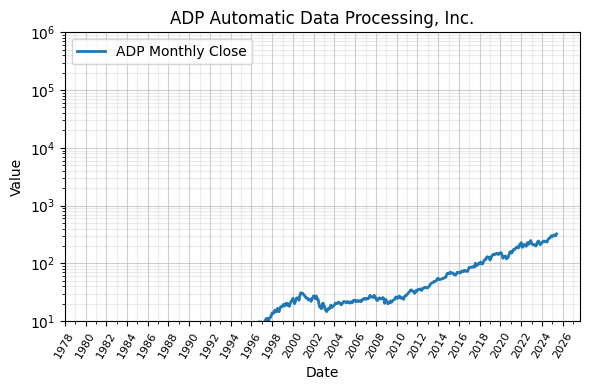

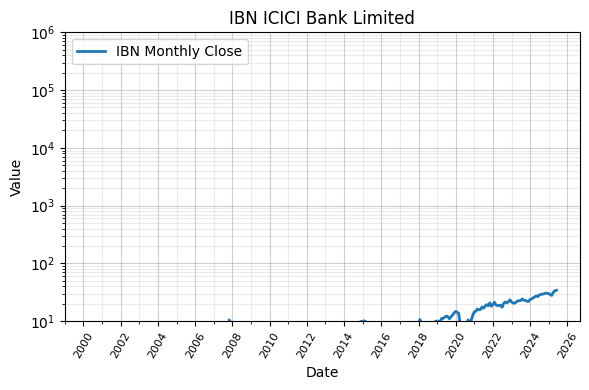

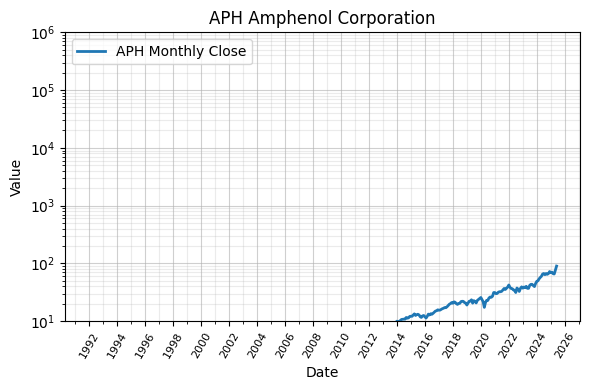

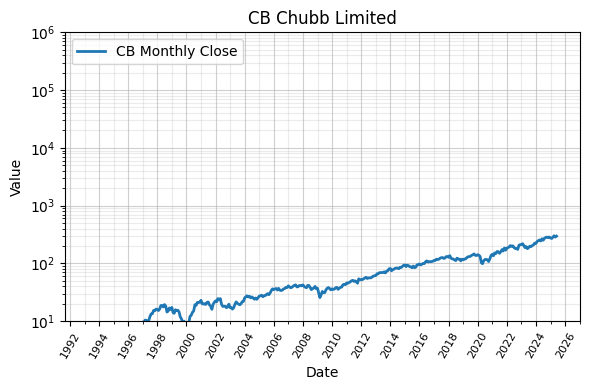

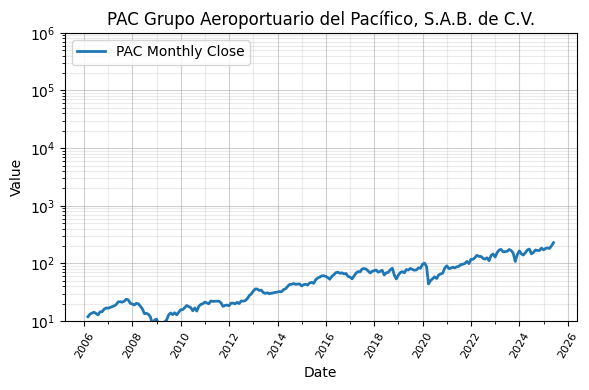

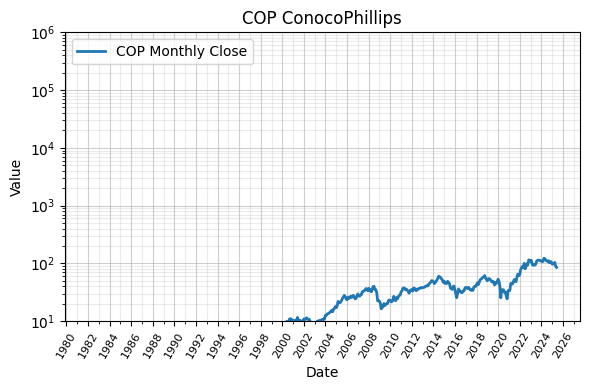

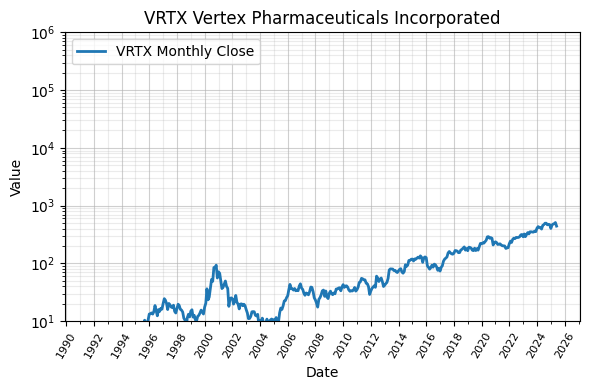

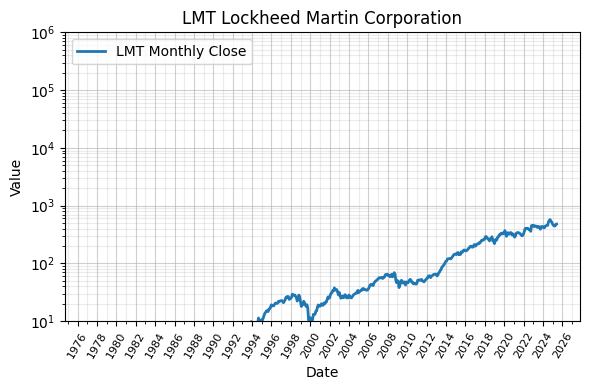

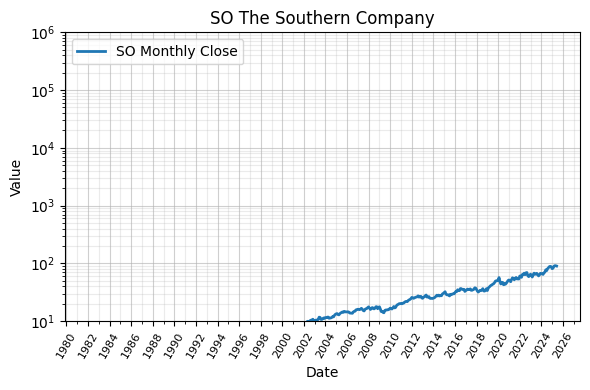

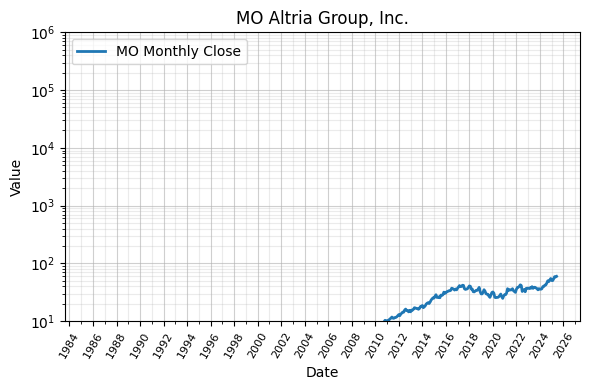

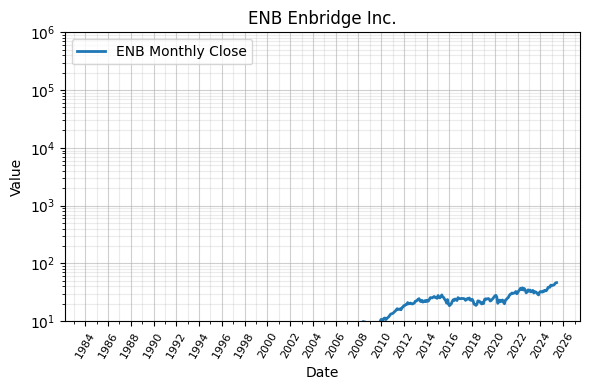

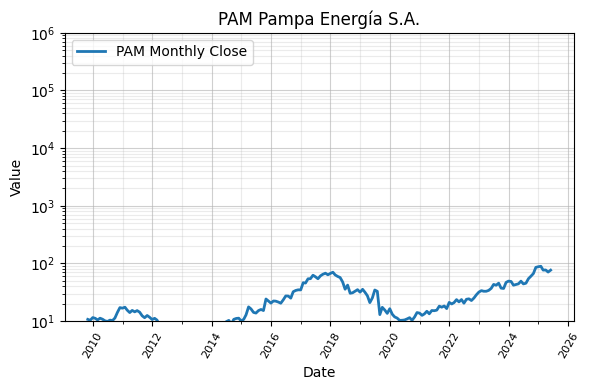

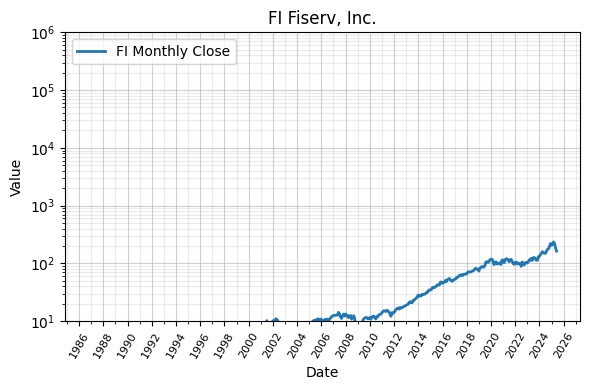

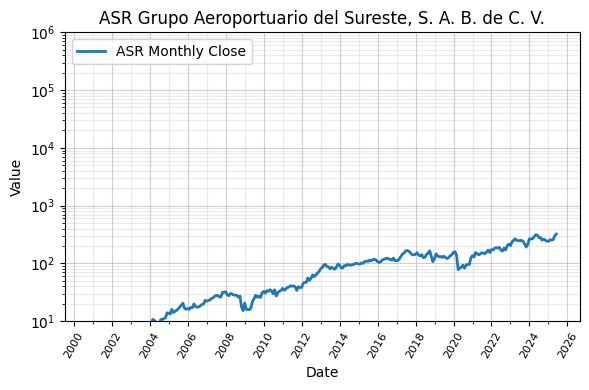

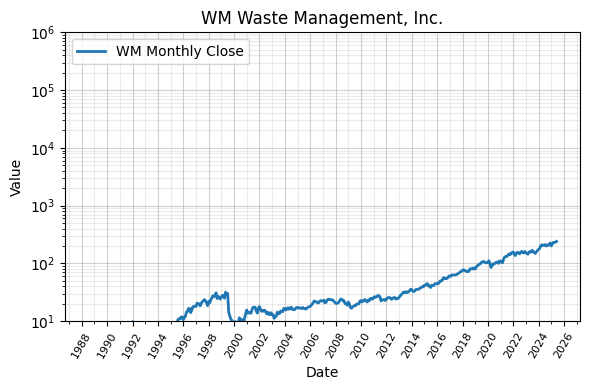

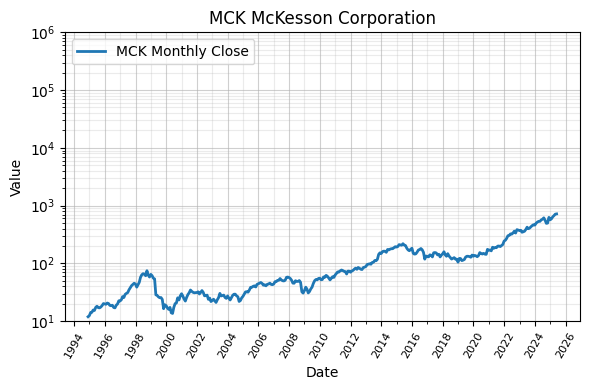

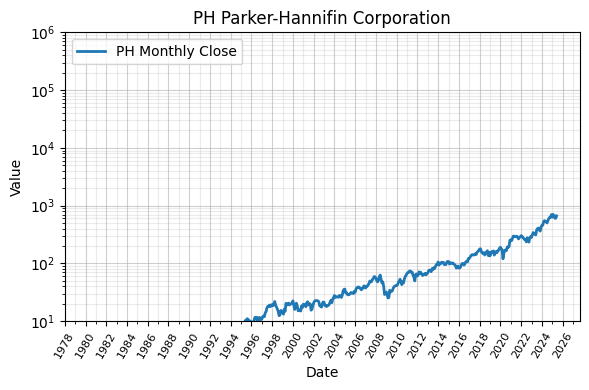

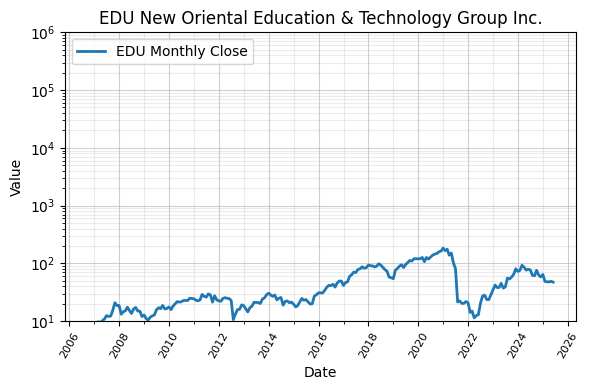

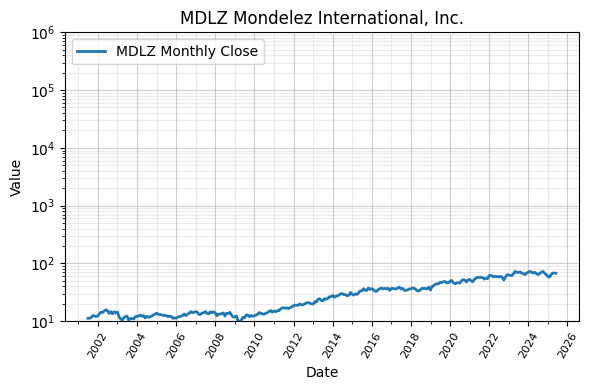

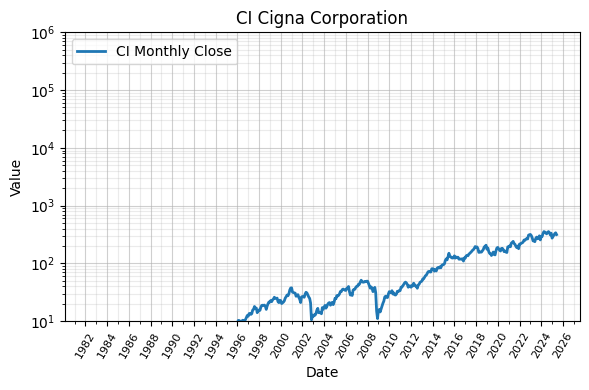

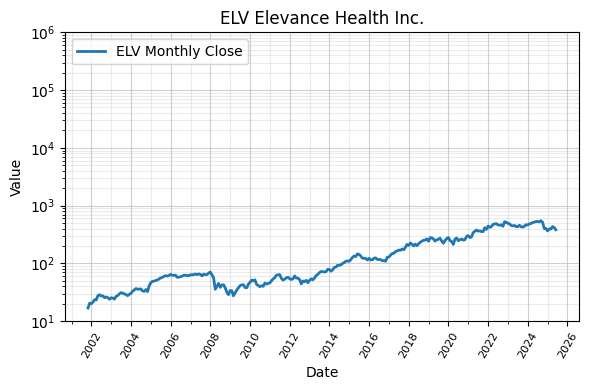

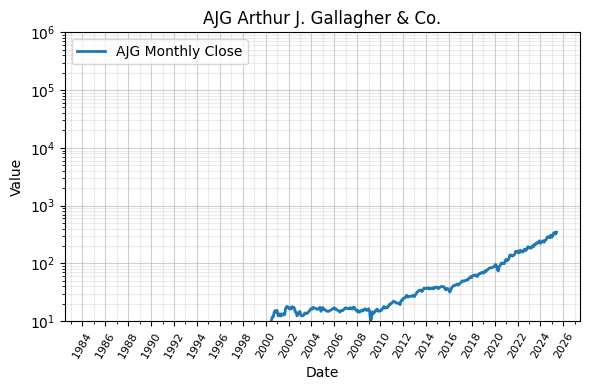

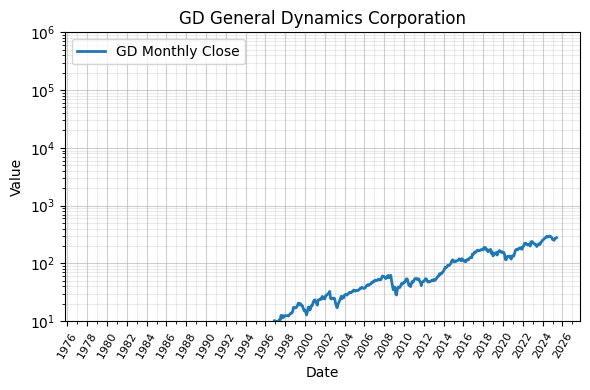

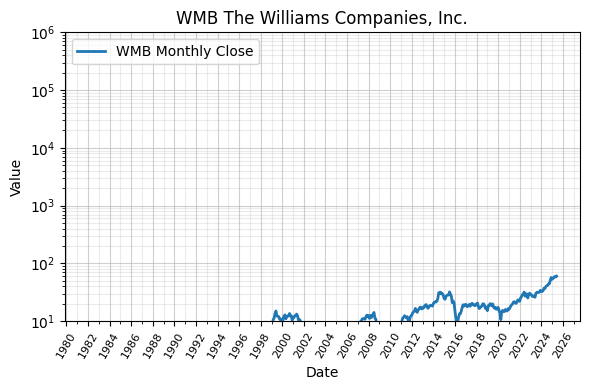

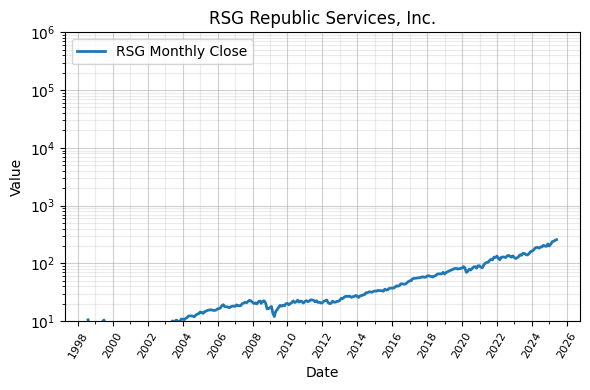

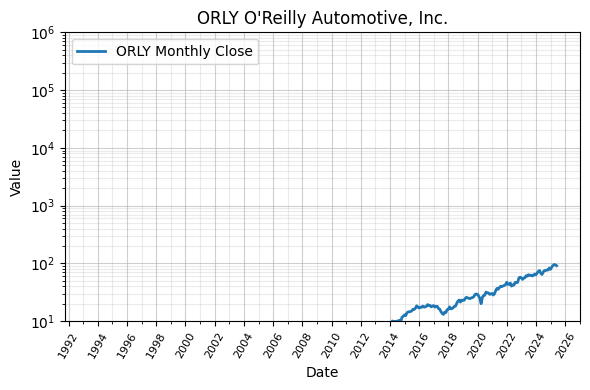

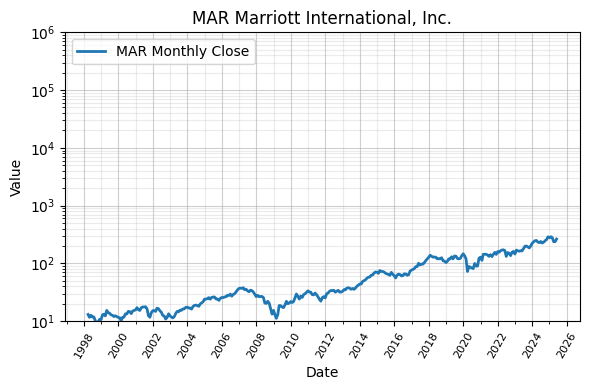

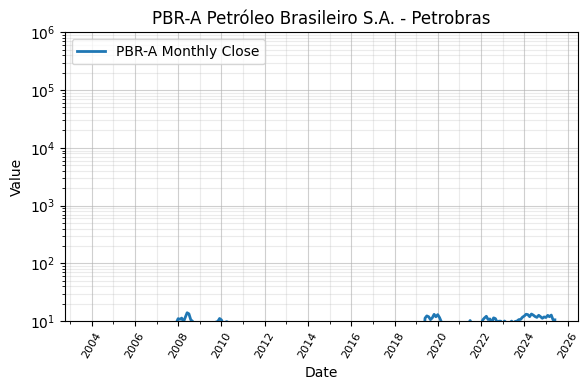

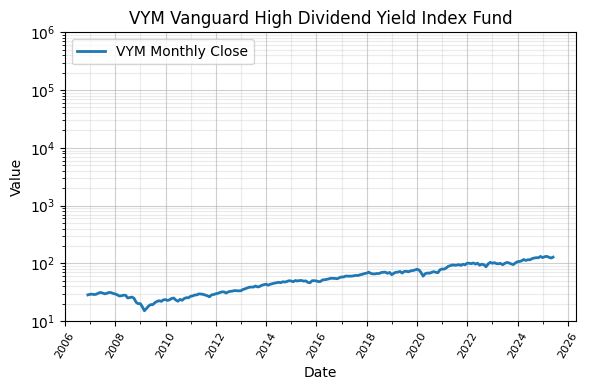

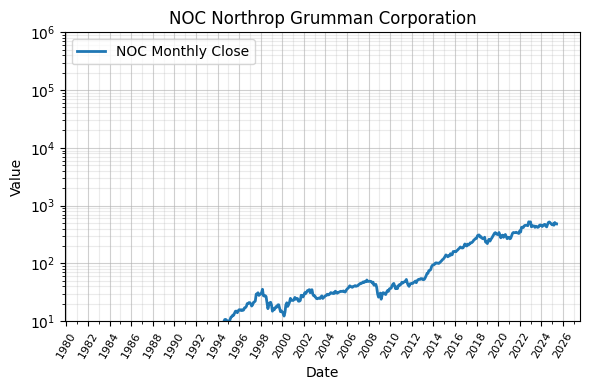

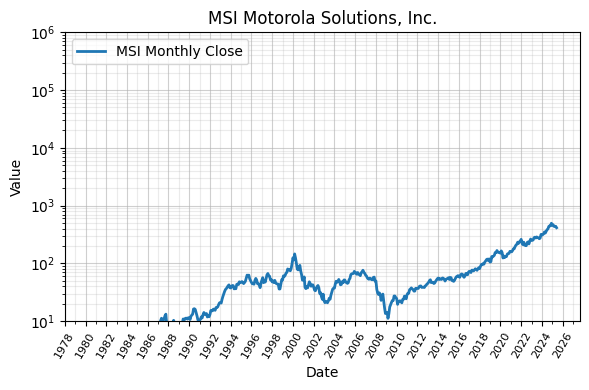

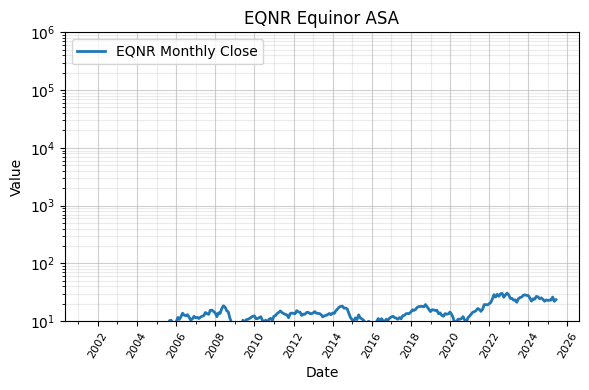

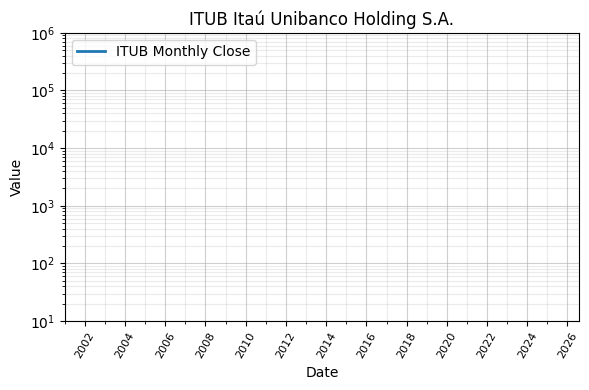

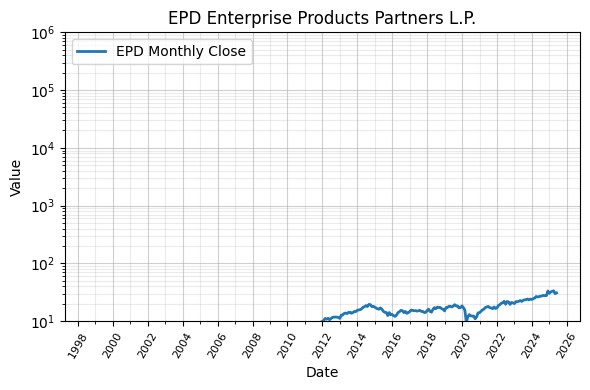

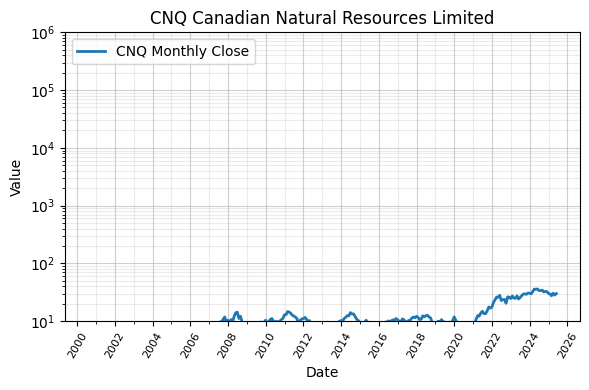

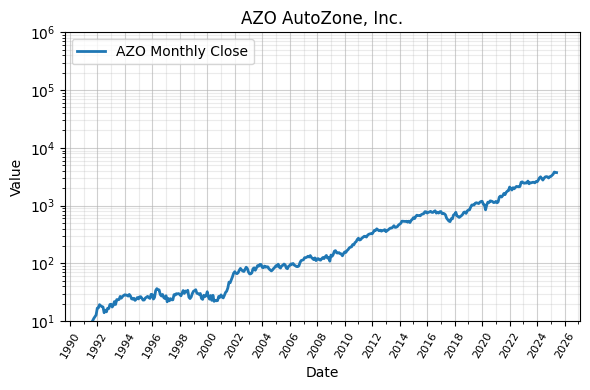

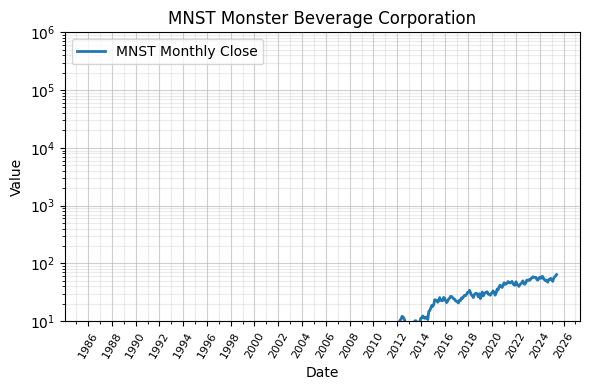

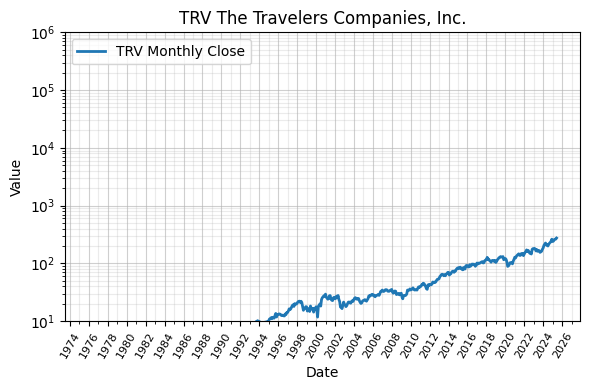

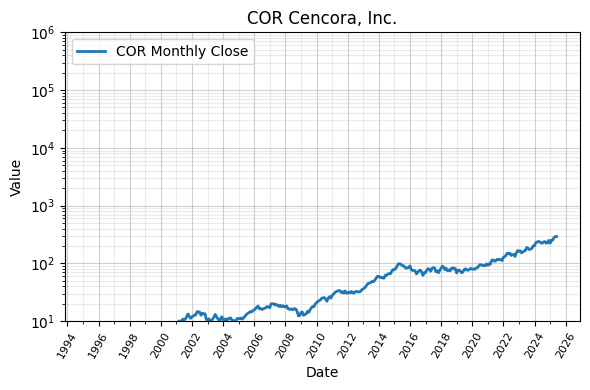

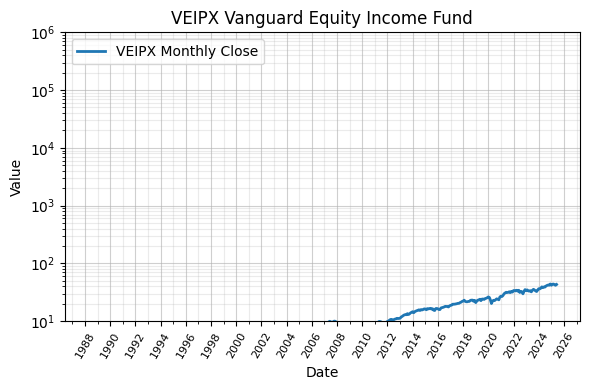

KeyboardInterrupt: 

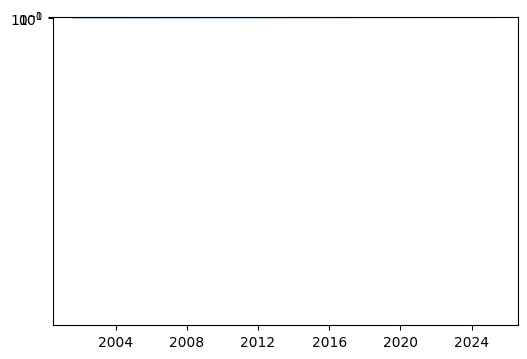

In [20]:
select(MonthlyClose() >> PlotEach())

In [3]:
candidates.df()

,ticker,weight
0,LTM,1.0
1,TSM,1.0
2,BSAC,1.0
3,NVDA,1.0
4,MSFT,1.0
...,...,...
4385,NVCR,1.0
4386,SBLK,1.0
4387,AEVA,1.0
4388,TGI,1.0


Cropping 2 symbols to common date range...
Common date range: 1980-12-14 to 2025-06-22
Cropped 2 time series to common range


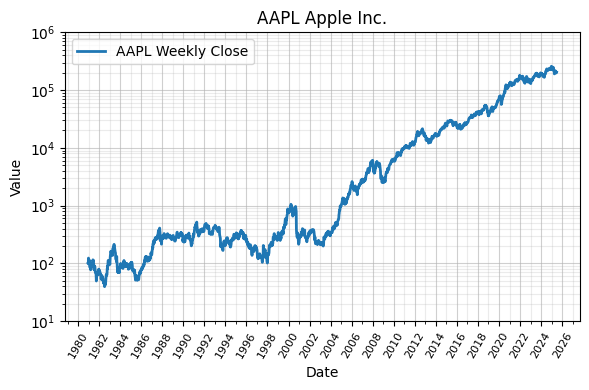

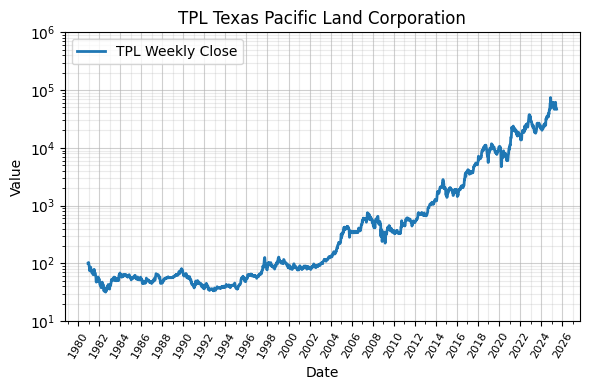

,ticker,weight,Name,Industry,Sector,CAGR[2014],CAGR[2015],CAGR[2016],CAGR[2017],CAGR[2018],CAGR[2019],CAGR[2020],CAGR[2021],CAGR[2022]
0,AAPL,1,Apple Inc.,Consumer Electronics,Technology,0.588918,0.092256,0.109128,0.548022,0.110323,0.845475,0.724206,0.289816,-0.175515
1,TPL,1,Texas Pacific Land Corporation,Oil & Gas Exploration & Production,Energy,0.513829,0.318487,1.608014,0.404889,0.382072,0.310584,-0.217471,0.819386,1.278332
